In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
dt = ds.Coco("/home/wanderer2414/coco2017/")
# x = dt.getTrainTensor(0)
# ds.ImgWrite("test0.png", ds.TensorToImg(x))

loading annotations into memory...
Done (t=7.72s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [2]:
import YOLO
from torch import device
model = YOLO.Model(device("cuda"))
model.train(dt)

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([7, 7, 100])) that is different to the input size (torch.Size([1, 7, 7, 100])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([7, 7, 2])) that is different to the input size (torch.Size([1, 7, 7, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[00:03:12] 3.49253249168396               ██████████████████████████████████████████████████████████ 100      /      100


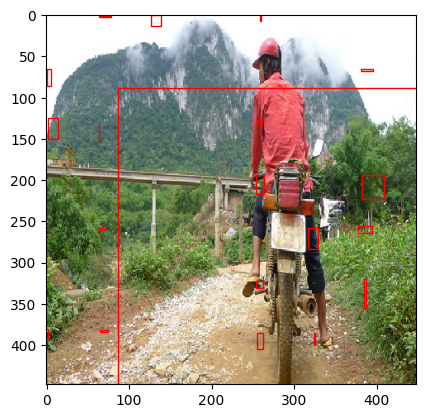

In [45]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from dataset import Dataset, TensorToImg
x = dt.getTrainTensor(0).to(device("cuda"))
x = torch.nn.functional.interpolate(x, size=(448, 448), mode="nearest")

plt.imshow(TensorToImg(x.detach().to(device("cpu"))))

result: torch.Tensor = model.model(x).reshape(-1,110).detach().to(device("cpu"))
row = torch.arange(7).view(1, 7, 1, 1).expand(1,7,7,1).reshape(-1, 1)
col = torch.arange(7).view(1, 1, 7, 1).expand(1,7,7,1).reshape(-1, 1)

for r, c, box in zip(row, col, result):
    x,y,w,h,cls = box[:5]
    x = (x+c)/7*448
    y = (y+r)/7*448
    h = (h * 448).abs()
    w = (w * 448).abs()
    cls = torch.nn.functional.sigmoid(cls)
    if (cls>0.5):
        rect = patches.Rectangle((x,y), w, h, facecolor='none', edgecolor='red')
        plt.subplot().add_patch(rect)
